Project ROOT identified as: /Users/imalsky/Documents/Emulator
SRC directory added to sys.path: /Users/imalsky/Documents/Emulator/src
Loading configuration from: /Users/imalsky/Documents/Emulator/inputs/model_input_params.jsonc
Running on: cpu
Loading dataset from: /Users/imalsky/Documents/Emulator/data/normalized_profiles
Selecting 1000 random samples from the test set for plotting.
Loading model from: /Users/imalsky/Documents/Emulator/data/model/best_model.pt
Loading normalization metadata from: /Users/imalsky/Documents/Emulator/data/normalized_profiles/normalization_metadata.json


/opt/homebrew/Caskroom/miniforge/base/envs/nn/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Running model inference for selected samples...
Inference time for 1000 profiles: 6704.3 ms
Denormalizing global variables...
Calculating MAE for target: albedo...
Generating corner plot...
Corner plot saved to: /Users/imalsky/Documents/Emulator/data/model/emulator_performance_corner_plot.png


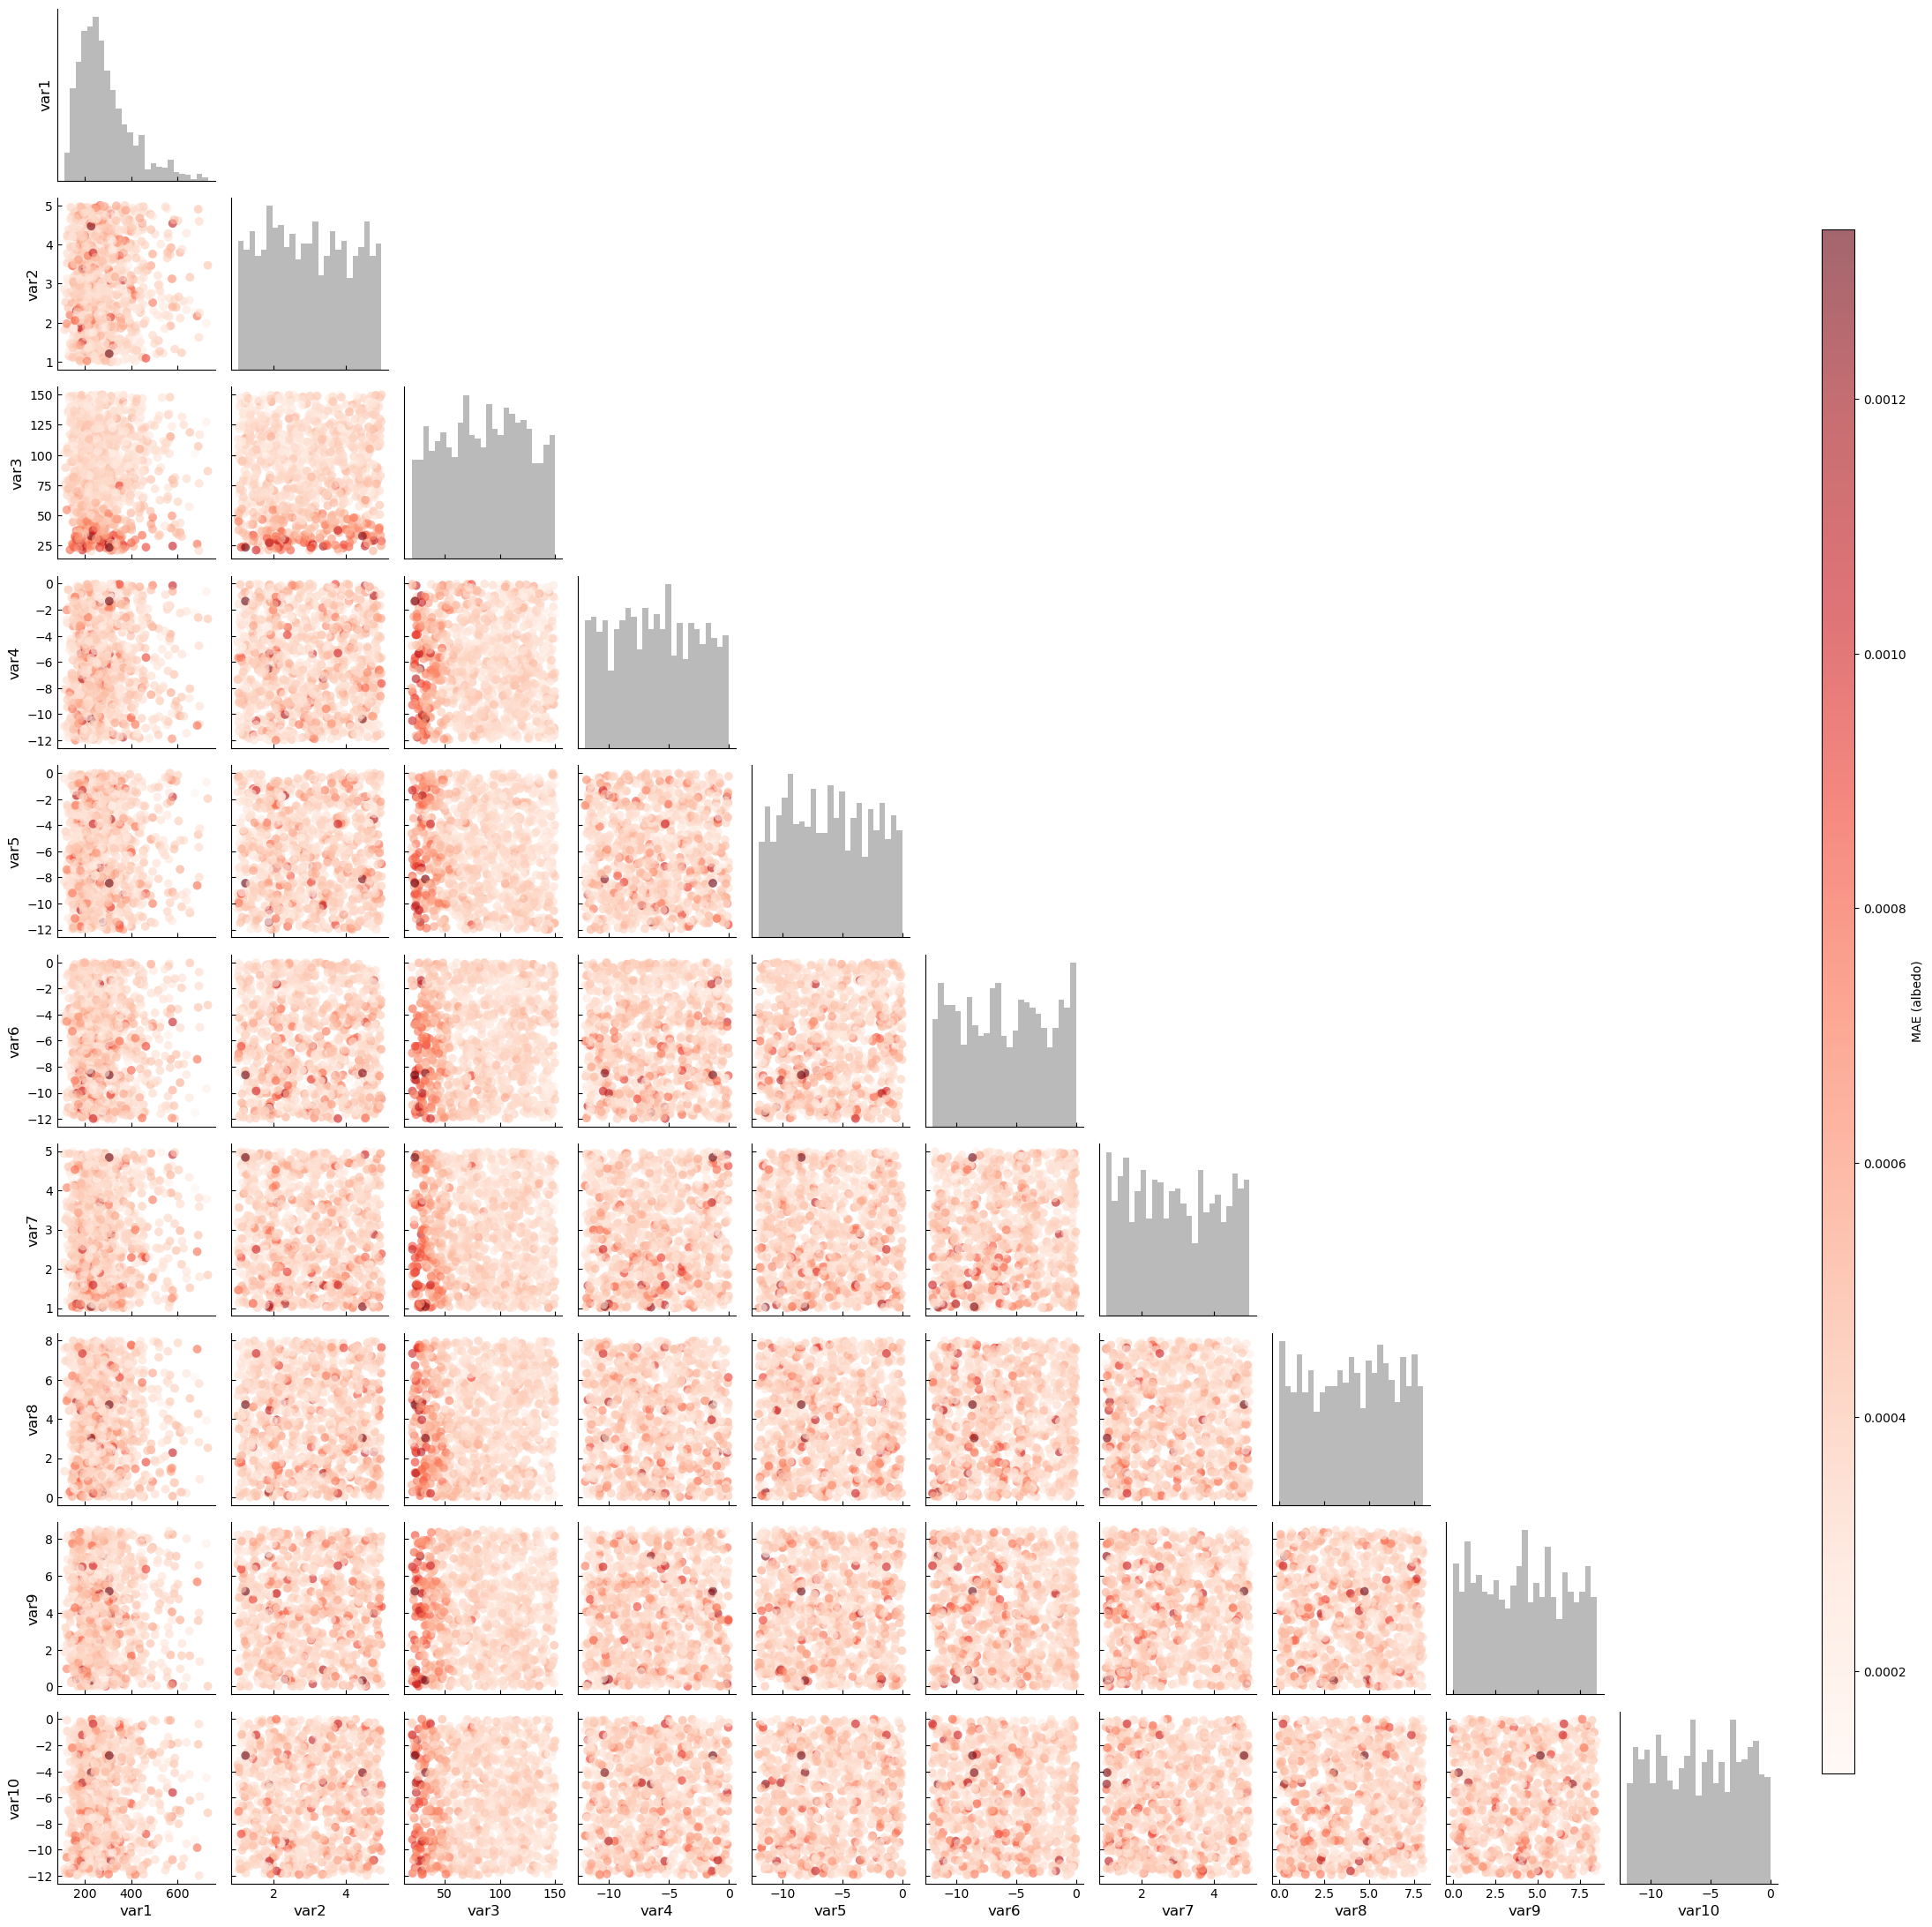

In [15]:
#!/usr/bin/env python3
# ================================================================
# Emulator Performance Corner Plot
# Visualizes global variable distributions and pairwise relationships,
# colored by Mean Absolute Error (MAE) of predictions.
# ================================================================
import sys
import json
import random
import time
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from torch.utils.data import DataLoader, Subset

# --- Determine ROOT and SRC paths ---
# This assumes the script is run from a location where traversing upwards
# will find a directory named 'src'. Adjust if your structure is different.
try:
    ROOT = Path.cwd()
    while not (ROOT / "src").is_dir():
        if ROOT.parent == ROOT: # Reached the filesystem root
            raise FileNotFoundError("Could not find a 'src' directory above the current working directory.")
        ROOT = ROOT.parent
    SRC = ROOT / "src"
    if str(SRC) not in sys.path:
        sys.path.insert(0, str(SRC))
    print(f"Project ROOT identified as: {ROOT}")
    print(f"SRC directory added to sys.path: {SRC}")
except FileNotFoundError as e:
    print(f"Error determining project structure: {e}")
    print("Please ensure you are running this script from within your project,")
    print("or that the 'src' directory is in the expected location relative to the script.")
    sys.exit(1)

# ---------- project paths (relative to ROOT) ----------------------------------------
CFG_PATH   = ROOT / "inputs" / "model_input_params.jsonc"
MODEL_PATH = ROOT / "data" / "model" / "best_model.pt"
TEST_SET_INFO_PATH  = ROOT / "data" / "model" / "test_set_info.json"
NORMALIZED_DATA_DIR  = ROOT / "data" / "normalized_profiles"
METADATA_PATH  = NORMALIZED_DATA_DIR / "normalization_metadata.json"

# ---------- internal imports (after sys.path modification) -------------------------------------
try:
    from utils      import load_config
    from dataset    import AtmosphericDataset, create_multi_source_collate_fn
    from model      import create_prediction_model
    from normalizer import DataNormalizer # Your DataNormalizer class
except ImportError as e:
    print(f"Error importing project modules: {e}")
    print("Please ensure that 'src' directory is correctly added to sys.path and contains necessary modules.")
    sys.exit(1)

# ---------- Configuration for the Plot ---------------------------------------
NUM_SAMPLES_FOR_PLOT = 1000  # Number of random samples from the test set
SCATTER_POINT_SIZE = 50      # Scatter plot point size (reduced for clarity)
SCATTER_ALPHA = 0.6         # Scatter plot point alpha (transparency)
MAE_COLORMAP = 'Reds'       # Colormap for MAE
HISTOGRAM_BINS = 25         # Number of bins for histograms on the diagonal
FIGSIZE_PER_VAR = 2.5       # Inches per variable for figure size calculation
LABEL_FONTSIZE = 12          # Fontsize for axis labels
TICK_LABELSIZE = 10          # Fontsize for tick labels
TITLE_FONTSIZE = 16         # Fontsize for the main title

# --- Set up Matplotlib Style ---
# Using 'default' and customizing.
# For a different base style, you could use:
# plt.style.use('seaborn-v0_8-whitegrid')
# plt.style.use('seaborn-v0_8-ticks')
# Or your custom style:
# if (ROOT / '../jupyter_notebooks/science.mplstyle').exists():
#     plt.style.use(str(ROOT / '../jupyter_notebooks/science.mplstyle'))
# else:
#     print("Custom 'science.mplstyle' not found, using default.")
plt.style.use('default')


def main_plotter():
    # ---------- Load Configuration and Set Up Objects -----------------------------
    print(f"Loading configuration from: {CFG_PATH}")
    cfg = load_config(CFG_PATH)
    if cfg is None:
        print(f"Failed to load configuration from {CFG_PATH}. Exiting.")
        sys.exit(1)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Running on: {device}")

    print(f"Loading dataset from: {NORMALIZED_DATA_DIR}")
    ds = AtmosphericDataset(
        data_folder=NORMALIZED_DATA_DIR,
        input_variables=cfg["input_variables"],
        target_variables=cfg["target_variables"],
        global_variables=cfg.get("global_variables", []),
        sequence_types=cfg["sequence_types"],
        sequence_lengths=cfg["sequence_lengths"],
        output_seq_type=cfg["output_seq_type"],
        validate_profiles=False,
    )

    if not TEST_SET_INFO_PATH.exists():
        print(f"Test set info file not found at: {TEST_SET_INFO_PATH}. Exiting.")
        sys.exit(1)

    test_ids_data = json.load(TEST_SET_INFO_PATH.open())["test_indices"]
    
    num_available_test_samples = len(test_ids_data)
    actual_num_samples = min(NUM_SAMPLES_FOR_PLOT, num_available_test_samples)
    
    if actual_num_samples == 0:
        print("Error: No test samples available to plot. Exiting.")
        sys.exit(1)
    print(f"Selecting {actual_num_samples} random samples from the test set for plotting.")
    
    selected_indices = random.sample(test_ids_data, actual_num_samples)
    
    valid_selected_indices = [idx for idx in selected_indices if idx < len(ds)]
    if len(valid_selected_indices) != actual_num_samples:
        print(f"Warning: Some selected test indices were out of bounds for the dataset. Using {len(valid_selected_indices)} valid samples.")
        actual_num_samples = len(valid_selected_indices)
        if actual_num_samples == 0:
            print("Error: No valid test samples to plot after index validation. Exiting.")
            sys.exit(1)
    
    subset_for_plot = Subset(ds, valid_selected_indices)
    plot_dataloader = DataLoader(
        subset_for_plot,
        batch_size=actual_num_samples,
        collate_fn=create_multi_source_collate_fn()
    )

    print(f"Loading model from: {MODEL_PATH}")
    model = create_prediction_model(cfg, device=device)
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device)["state_dict"])
    model.eval()

    print(f"Loading normalization metadata from: {METADATA_PATH}")
    meta = json.load(METADATA_PATH.open())

    # ---------- Get Data, Predictions, and Denormalize -----------------------------
    try:
        x_batch_dict, y_true_batch_tensor = next(iter(plot_dataloader))
    except StopIteration:
        print("Error: DataLoader yielded no data. Check dataset and indices.")
        sys.exit(1)
        
    x_batch_dict_device = {k: v.to(device) for k, v in x_batch_dict.items()}

    print("Running model inference for selected samples...")
    t0 = time.perf_counter()
    with torch.no_grad():
        y_pred_batch_tensor = model(x_batch_dict_device).cpu()
    infer_ms = (time.perf_counter() - t0) * 1e3
    print(f"Inference time for {actual_num_samples} profiles: {infer_ms:.1f} ms")

    global_var_names = cfg.get("global_variables", [])
    if not global_var_names:
        print("Error: 'global_variables' not found or empty in config. Cannot create plot.")
        sys.exit(1)
    
    num_global_vars = len(global_var_names)
    denormalized_globals = np.zeros((actual_num_samples, num_global_vars))

    if "global" not in x_batch_dict:
        print("Error: 'global' key not found in input batch dictionary. Check dataset output.")
        sys.exit(1)
        
    global_input_tensor = x_batch_dict["global"]

    print("Denormalizing global variables...")
    for i, var_name in enumerate(global_var_names):
        try:
            denormalized_globals[:, i] = DataNormalizer.denormalize(
                global_input_tensor[:, i],
                meta,
                var_name
            ).detach().numpy()
        except KeyError:
            print(f"Warning: Stats for global variable '{var_name}' not found in metadata. Using normalized values.")
            denormalized_globals[:, i] = global_input_tensor[:, i].detach().numpy() 
        except Exception as e:
            print(f"Error denormalizing global variable '{var_name}': {e}. Using normalized values.")
            denormalized_globals[:, i] = global_input_tensor[:, i].detach().numpy()

    target_var_to_calc_mae_for = cfg["target_variables"][0]
    target_var_idx_for_mae = 0

    print(f"Calculating MAE for target: {target_var_to_calc_mae_for}...")
    true_target_denorm = DataNormalizer.denormalize(
        y_true_batch_tensor[:, :, target_var_idx_for_mae],
        meta,
        target_var_to_calc_mae_for
    ).detach().numpy()

    pred_target_denorm = DataNormalizer.denormalize(
        y_pred_batch_tensor[:, :, target_var_idx_for_mae],
        meta,
        target_var_to_calc_mae_for
    ).detach().numpy()

    mae_per_sample = np.mean(np.abs(true_target_denorm - pred_target_denorm), axis=1)
    
    mae_min, mae_max = np.min(mae_per_sample), np.max(mae_per_sample)
    if mae_min == mae_max: # Avoids error with Normalize if all MAE values are the same
        mae_max += 1e-6 # Add a tiny offset
    norm_colors = mcolors.Normalize(vmin=mae_min, vmax=mae_max)

    # ---------- Create the Corner Plot --------------------------------------------
    print("Generating corner plot...")
    fig, axes = plt.subplots(
        num_global_vars, num_global_vars, 
        figsize=(FIGSIZE_PER_VAR * num_global_vars, FIGSIZE_PER_VAR * num_global_vars)
    )
    
    if num_global_vars == 1:
        axes = np.array([[axes]]) # Ensure axes is always 2D for consistent indexing

    scatter_artist = None # To store the scatter plot for the colorbar

    for i in range(num_global_vars): # Row index (y-axis of subplot grid)
        for j in range(num_global_vars): # Column index (x-axis of subplot grid)
            ax = axes[i, j]

            # Diagonal: Histogram of the i-th (or j-th) global variable
            if i == j:
                ax.hist(denormalized_globals[:, i], bins=HISTOGRAM_BINS, density=True, color='darkgrey', alpha=0.8)
                ax.set_yticks([]) # No y-ticks for histograms
            
            # Lower triangle: Scatter plot of var_j vs var_i, colored by MAE
            elif i > j:
                scatter_artist = ax.scatter(
                    denormalized_globals[:, j], # x-data
                    denormalized_globals[:, i], # y-data
                    c=mae_per_sample,
                    cmap=MAE_COLORMAP,
                    norm=norm_colors,
                    s=SCATTER_POINT_SIZE,
                    alpha=SCATTER_ALPHA,
                    edgecolors='none'
                )
            # Upper triangle: Empty
            else:
                ax.set_visible(False)

            # --- Aesthetics for visible subplots ---
            if ax.get_visible():
                # Spines (remove top and right)
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)
                
                # Tick direction
                ax.tick_params(axis='both', which='major', direction='in', labelsize=TICK_LABELSIZE)
                ax.tick_params(axis='both', which='minor', direction='in')


                # Set labels only on the outer plots
                if j == 0: # Leftmost column: set y-label
                    ax.set_ylabel(global_var_names[i], fontsize=LABEL_FONTSIZE)
                else: # Hide y-tick labels for inner plots
                    ax.set_yticklabels([])
                
                if i == num_global_vars - 1: # Bottom row: set x-label
                    ax.set_xlabel(global_var_names[j], fontsize=LABEL_FONTSIZE)
                else: # Hide x-tick labels for inner plots
                    ax.set_xticklabels([])
                
                # For diagonal plots (histograms), ensure x-label is set if it's on the bottom row
                if i == j and i != num_global_vars -1: # Diagonal not on bottom row
                     ax.set_xticklabels([])


    #fig.suptitle(f"Emulator Global Variable Relationships vs. MAE ({target_var_to_calc_mae_for})", fontsize=TITLE_FONTSIZE, y=0.99)
    
    # Adjust subplot spacing for a tighter layout
    fig.subplots_adjust(hspace=0.1, wspace=0.1, left=0.1, bottom=0.1, right=0.88, top=0.95)

    if scatter_artist:
        # Position: [left, bottom, width, height] in figure coordinates
        cbar_ax = fig.add_axes([0.90, 0.15, 0.015, 0.7]) 
        fig.colorbar(scatter_artist, cax=cbar_ax, label=f"MAE ({target_var_to_calc_mae_for})")
    elif num_global_vars == 1 and axes[0,0].get_visible(): # Only a histogram was plotted
        print("Only one global variable; scatter plot and MAE colorbar are not applicable.")
    
    # fig.tight_layout(rect=[0.05, 0.05, 0.9, 0.97]) # May conflict with subplots_adjust

    plot_filename = ROOT / "data" / "model" / "emulator_performance_corner_plot.png"
    plt.savefig(plot_filename, dpi=200) # Increased DPI for better quality
    print(f"Corner plot saved to: {plot_filename}")
    plt.show()


if __name__ == "__main__":
    main_plotter()
